In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
import joblib

# Set directories
data_dir = 'inputs'
train_path = os.path.join(data_dir, 'train')
validation_path = os.path.join(data_dir, 'validation')
test_path = os.path.join(data_dir, 'test')

# Load the image shape we saved earlier
image_shape = joblib.load("outputs/v1/image_shape.pkl")
print(f"Using image shape: {image_shape}")

Using image shape: (256, 256, 3)


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Initialize the generator with transformations
job_id = 'v1'
batch_size = 16

image_gen = ImageDataGenerator(rotation_range=20,
                               width_shift_range=0.1,
                               height_shift_range=0.1,
                               shear_range=0.1,
                               zoom_range=0.1,
                               horizontal_flip=True,
                               fill_mode='nearest')

# Setup the generators for Train, Validation, and Test
train_set = image_gen.flow_from_directory(train_path,
                                          target_size=image_shape[:2],
                                          color_mode='rgb',
                                          batch_size=batch_size,
                                          class_mode='binary',
                                          shuffle=True)

validation_set = ImageDataGenerator().flow_from_directory(validation_path,
                                                          target_size=image_shape[:2],
                                                          color_mode='rgb',
                                                          batch_size=batch_size,
                                                          class_mode='binary',
                                                          shuffle=False)

test_set = ImageDataGenerator().flow_from_directory(test_path,
                                                    target_size=image_shape[:2],
                                                    color_mode='rgb',
                                                    batch_size=batch_size,
                                                    class_mode='binary',
                                                    shuffle=False)

# Save the class indices (0 for healthy, 1 for mildew)
joblib.dump(value=train_set.class_indices, filename=f"outputs/{job_id}/class_indices.pkl")

Found 2944 images belonging to 2 classes.
Found 420 images belonging to 2 classes.
Found 844 images belonging to 2 classes.


['outputs/v1/class_indices.pkl']

In [14]:
import joblib
# Load the image shape we saved in the previous notebook
image_shape = joblib.load("outputs/v1/image_shape.pkl")
print(f"Confirmed image shape: {image_shape}")

Confirmed image shape: (256, 256, 3)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D

def create_tf_model():
    model = Sequential()

    # First Convolutional Layer
    model.add(Conv2D(filters=32, kernel_size=(3,3), input_shape=image_shape, activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Second Convolutional Layer
    model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Third Convolutional Layer
    model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Flatten the data to 1D for the Dense layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))

    # Dropout to prevent overfitting (LO5.4)
    model.add(Dropout(0.5))

    # Output layer (1 neuron for binary classification: Healthy or Mildew)
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    
    return model

model = create_tf_model()
model.summary()

c:\Users\biv7s\.vscode\vs-projects\cherry-mildew-detector\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,429,377 (28.34 MB)

 Trainable params: 7,429,377 (28.34 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss doesn't improve for 3 consecutive epochs
early_stop = EarlyStopping(monitor='val_loss', patience=3)

# Start the training
# We use 20 epochs, but early_stop might end it sooner
model_history = model.fit(train_set,
                          epochs=20,
                          validation_data=validation_set,
                          callbacks=[early_stop],
                          verbose=1)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 166s 899ms/step - accuracy: 0.7215 - loss: 5.5869 - val_accuracy: 0.8357 - val_loss: 0.4326
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.7721 - loss: 0.5440 - val_accuracy: 0.8643 - val_loss: 0.5096
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.8132 - loss: 0.4941 - val_accuracy: 0.9524 - val_loss: 0.2589
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 164s 889ms/step - accuracy: 0.8801 - loss: 0.3653 - val_accuracy: 0.9643 - val_loss: 0.2342
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.8699 - loss: 0.4012 - val_accuracy: 0.9310 - val_loss: 0.2812
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 181s 987ms/step - accuracy: 0.8947 - loss: 0.3178 - val_accuracy: 0.9524 - val_loss: 0.2056
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.9175 - loss: 0.2717 - val_accuracy: 0.9619 - val_loss: 0.1503
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.9344 - loss: 0.2089 -

In [17]:
# Save the model
model.save('outputs/v1/cherry_leaves_model.h5')

# Save the training history for plotting later
joblib.dump(value=model_history.history, filename="outputs/v1/model_history.pkl")

print("Model and history saved successfully!")

Model and history saved successfully!


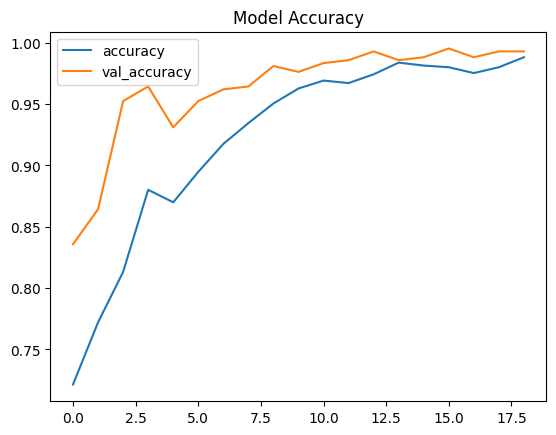

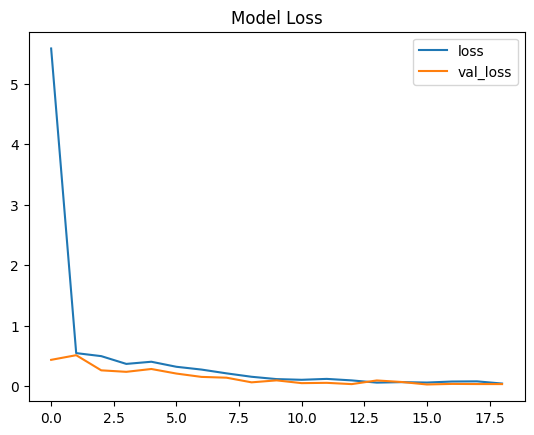

In [18]:
losses = pd.DataFrame(model.history.history)

# Plot accuracy
losses[['accuracy', 'val_accuracy']].plot()
plt.title('Model Accuracy')
plt.show()

# Plot loss
losses[['loss', 'val_loss']].plot()
plt.title('Model Loss')
plt.show()

In [19]:
# Evaluate the model on the test set
test_evaluation = model.evaluate(test_set)

print(f"Test Loss: {test_evaluation[0]}")
print(f"Test Accuracy: {test_evaluation[1]}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.9941 - loss: 0.0189
Test Loss: 0.01888834498822689
Test Accuracy: 0.9940758347511292


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


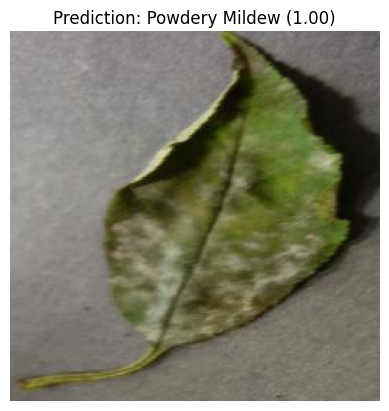

In [20]:
from tensorflow.keras.preprocessing import image

# Load a random image from the test set
test_image_path = os.path.join(test_path, 'powdery_mildew', os.listdir(os.path.join(test_path, 'powdery_mildew'))[0])
img = image.load_img(test_image_path, target_size=image_shape[:2])

# Prepare the image for prediction
img_array = image.img_to_array(img) / 255
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)
if prediction > 0.5:
    result = 'Powdery Mildew'
else:
    result = 'Healthy'

plt.imshow(img)
plt.title(f"Prediction: {result} ({prediction[0][0]:.2f})")
plt.axis('off')
plt.show()